In [ ]:
# git clone https://github.com/huggingface/lerobot.git
# cd lerobot
# pip install -e .
# pip install -e ".[hilserl]" # simulation environment 
# conda install ffmpeg matplotlib
import lerobot
print(lerobot.__version__)

0.5.2


In [10]:
import torch, torchcodec
print(torch.__version__)
print(torchcodec.__version__)

objc[35906]: Class AVFFrameReceiver is implemented in both /opt/anaconda3/envs/lerobot_py312/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x1775e03a8) and /opt/anaconda3/envs/lerobot_py312/lib/libavdevice.62.1.100.dylib (0x3434207a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[35906]: Class AVFAudioReceiver is implemented in both /opt/anaconda3/envs/lerobot_py312/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x1775e03f8) and /opt/anaconda3/envs/lerobot_py312/lib/libavdevice.62.1.100.dylib (0x3434207f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


2.10.0
0.10.0


In [5]:
# This cell loads a LeRobot dataset from the Hugging Face Hub
# and forces the video backend to use PyAV instead of TorchCodec.

import torch
from pprint import pprint

from lerobot.datasets.lerobot_dataset import LeRobotDataset
from lerobot.datasets.dataset_metadata import LeRobotDatasetMetadata

repo_id = "lerobot/aloha_sim_insertion_scripted"

meta = LeRobotDatasetMetadata(repo_id)

# Force video_backend="pyav" to avoid TorchCodec loading issues on macOS
dataset = LeRobotDataset(repo_id, video_backend="pyav")

print("Dataset loaded successfully.")
print(f"Repo ID: {repo_id}")
print(f"Video backend: pyav")

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 49932.19it/s]

Dataset loaded successfully.
Repo ID: lerobot/aloha_sim_insertion_scripted
Video backend: pyav


In [2]:
# This cell prints dataset metadata including features, episode count, and frame count.

print("===== Dataset Metadata =====")
print(f"Total episodes: {meta.total_episodes}")
print(f"Total frames: {meta.total_frames}")
print(f"FPS: {meta.fps}")
print(f"Robot type: {meta.robot_type}")

print("\n===== Camera Keys =====")
print(meta.camera_keys)

print("\n===== Tasks =====")
pprint(meta.tasks)

print("\n===== Features =====")
pprint(meta.features)

print("\n===== Dataset Object Summary =====")
print(dataset)

print("\n===== Dataset Selection Summary =====")
print(f"Selected episodes: {dataset.num_episodes}")
print(f"Selected frames: {dataset.num_frames}")

===== Dataset Metadata =====
Total episodes: 50
Total frames: 20000
FPS: 50
Robot type: aloha

===== Camera Keys =====
['observation.images.top']

===== Tasks =====
                                 task_index
task                                       
Insert the peg into the socket.           0

===== Features =====
{'action': {'dtype': 'float32',
            'fps': 50.0,
            'names': {'motors': ['left_waist',
                                 'left_shoulder',
                                 'left_elbow',
                                 'left_forearm_roll',
                                 'left_wrist_angle',
                                 'left_wrist_rotate',
                                 'left_gripper',
                                 'right_waist',
                                 'right_shoulder',
                                 'right_elbow',
                                 'right_forearm_roll',
                                 'right_wrist_angle',
              

Episode 0 frame range: [0, 400)
Number of frames in episode 0: 400


/opt/anaconda3/envs/lerobot_py312/lib/python3.12/site-packages/torchvision/io/_video_deprecation_warning.py:9: UserWarning: The video decoding and encoding capabilities of torchvision are deprecated from version 0.22 and will be removed in version 0.24. We recommend that you migrate to TorchCodec, where we'll consolidate the future decoding/encoding capabilities of PyTorch: https://github.com/pytorch/torchcodec
  warnings.warn(
/var/folders/cs/x9dhh7d11xs530bnby8f9kfm0000gn/T/ipykernel_35906/2844577276.py:23: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  actions = torch.tensor(actions).numpy()


Action array shape: (400, 14)


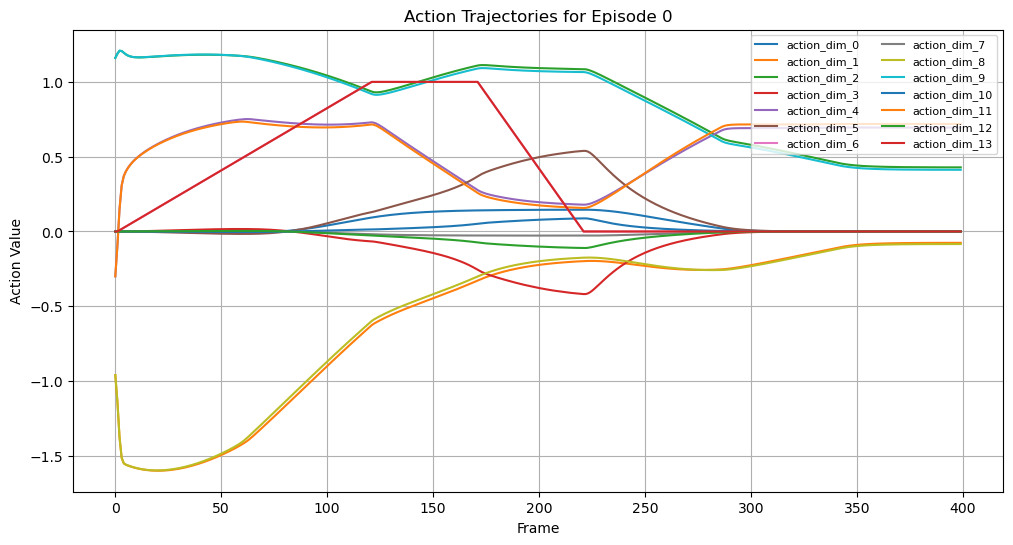

In [6]:
# This cell extracts all frames from episode 0 and plots the action trajectories over time.

import matplotlib.pyplot as plt

episode_index = 0

# Get the global frame index range for episode 0
from_idx = dataset.meta.episodes["dataset_from_index"][episode_index]
to_idx = dataset.meta.episodes["dataset_to_index"][episode_index]

print(f"Episode {episode_index} frame range: [{from_idx}, {to_idx})")
print(f"Number of frames in episode {episode_index}: {to_idx - from_idx}")

# Collect action vectors for the full episode
actions = []
timestamps = []

for idx in range(from_idx, to_idx):
    sample = dataset[idx]
    actions.append(sample["action"].numpy())
    timestamps.append(sample["timestamp"].item() if hasattr(sample["timestamp"], "item") else sample["timestamp"])

actions = torch.tensor(actions).numpy()

print("Action array shape:", actions.shape)

# Plot all action dimensions
plt.figure(figsize=(12, 6))
for dim in range(actions.shape[1]):
    plt.plot(actions[:, dim], label=f"action_dim_{dim}")

plt.title(f"Action Trajectories for Episode {episode_index}")
plt.xlabel("Frame")
plt.ylabel("Action Value")
plt.legend(loc="upper right", ncol=2, fontsize=8)
plt.grid(True)
plt.show()

Using camera key: observation.images.top


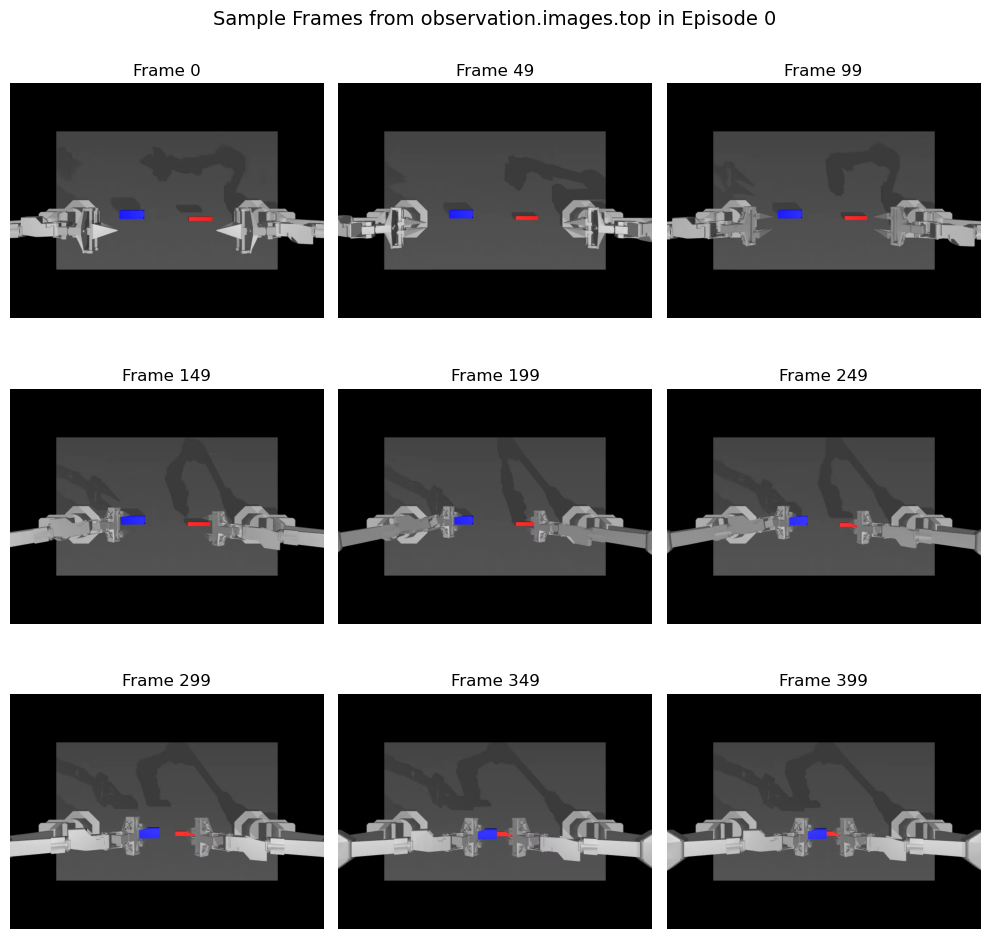

In [7]:
# This cell displays a grid of frames from the first available camera in episode 0.

import math
import numpy as np
import matplotlib.pyplot as plt

camera_key = dataset.meta.camera_keys[0]
print("Using camera key:", camera_key)

# Sample a small number of frames across the episode
num_frames_to_show = 9
frame_indices = np.linspace(from_idx, to_idx - 1, num_frames_to_show, dtype=int)

images = []
for idx in frame_indices:
    image_tensor = dataset[idx][camera_key]
    
    # Convert from PyTorch CHW to HWC for matplotlib
    image = image_tensor.permute(1, 2, 0).numpy()
    images.append(image)

rows = 3
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
axes = axes.flatten()

for ax, image, idx in zip(axes, images, frame_indices):
    ax.imshow(image)
    ax.set_title(f"Frame {idx}")
    ax.axis("off")

for ax in axes[len(images):]:
    ax.axis("off")

plt.suptitle(f"Sample Frames from {camera_key} in Episode {episode_index}", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# This cell loads a second dataset and compares its metadata structure with the first dataset.

second_repo_id = "lerobot/pusht"

second_meta = LeRobotDatasetMetadata(second_repo_id)
second_dataset = LeRobotDataset(second_repo_id)

print("===== First Dataset =====")
print(f"Repo ID: {repo_id}")
print(f"Episodes: {meta.total_episodes}")
print(f"Frames: {meta.total_frames}")
print(f"Camera keys: {meta.camera_keys}")
print(f"Robot type: {meta.robot_type}")

print("\n===== Second Dataset =====")
print(f"Repo ID: {second_repo_id}")
print(f"Episodes: {second_meta.total_episodes}")
print(f"Frames: {second_meta.total_frames}")
print(f"Camera keys: {second_meta.camera_keys}")
print(f"Robot type: {second_meta.robot_type}")

print("\n===== Feature Keys Comparison =====")
first_feature_keys = set(meta.features.keys())
second_feature_keys = set(second_meta.features.keys())

print("Common feature keys:")
pprint(sorted(first_feature_keys & second_feature_keys))

print("\nOnly in first dataset:")
pprint(sorted(first_feature_keys - second_feature_keys))

print("\nOnly in second dataset:")
pprint(sorted(second_feature_keys - first_feature_keys))

Fetching 8 files: 100%|██████████| 8/8 [00:00<00:00,  8.69it/s]

===== First Dataset =====
Repo ID: lerobot/aloha_sim_insertion_scripted
Episodes: 50
Frames: 20000
Camera keys: ['observation.images.top']
Robot type: aloha

===== Second Dataset =====
Repo ID: lerobot/pusht
Episodes: 206
Frames: 25650
Camera keys: ['observation.image']
Robot type: unknown

===== Feature Keys Comparison =====
Common feature keys:
['action',
 'episode_index',
 'frame_index',
 'index',
 'next.done',
 'observation.state',
 'task_index',
 'timestamp']

Only in first dataset:
['observation.images.top']

Only in second dataset:
['next.reward', 'next.success', 'observation.image']


In [ ]:
# This cell shows the command for launching LeRobot's built-in dataset visualizer.
!lerobot-dataset-viz --repo-id lerobot/pusht --episode-index 0

INFO 2026-04-08 11:37:31 aset_viz.py:296 Loading dataset
INFO 2026-04-08 11:37:31 eo_utils.py:108 Using video codec: libsvtav1
Fetching 4 files: 100%|████████████████████████| 4/4 [00:00<00:00, 29382.16it/s]
Download complete: : 0.00B [00:00, ?B/s]              
INFO 2026-04-08 11:37:32 aset_viz.py:108 Loading dataloader
INFO 2026-04-08 11:37:32 aset_viz.py:115 Starting Rerun
[2026-04-08T18:37:32Z INFO  re_grpc_server] Listening for gRPC connections on 0.0.0.0:9876. Connect by running `rerun --connect rerun+http://127.0.0.1:9876/proxy`
INFO 2026-04-08 11:37:33 aset_viz.py:133 Logging to Rerun
  0%|                                                     | 0/6 [00:00<?, ?it/s]objc[36402]: Class AVFFrameReceiver is implemented in both /opt/anaconda3/envs/lerobot_py312/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x17c0283a8) and /opt/anaconda3/envs/lerobot_py312/lib/libavdevice.62.1.100.dylib (0x3022e87a8). This may cause spurious casting failures and mysterious crashe